## 2. Synthetic Data Generation
For this demonstration, we'll generate a 2D dataset that is partly on a line (inliers) and partly random (outliers).


In [1]:
import numpy as np
import matplotlib.pyplot as plt
import random

def init_random(seed=None):
    if seed is not None:
        np.random.seed(seed)
        random.seed(seed)

def generate_data(N, p, direction, inlier_ratio=0.5):
    WIDTH, HEIGHT = 640, 480
    p = np.array(p, dtype=float)
    direction = np.array(direction, dtype=float)
    direction /= np.linalg.norm(direction)

    N_inlier = int(N * inlier_ratio)
    N_outlier = N - N_inlier

    points = []

    diag = np.sqrt(WIDTH**2 + HEIGHT**2)
    for _ in range(N_inlier):
        t = (random.random() * diag) - diag / 2.0
        q = p + t * direction
        q[0] += np.random.normal(0.0, 10.0)
        q[1] += np.random.normal(0.0, 10.0)
        points.append(q)

    for _ in range(N_outlier):
        points.append((random.random() * WIDTH, random.random() * HEIGHT))

    return np.array(points, dtype=float)


In [ ]:
init_random(seed=0)

N = 1000
p = (240.0, 320.0)
alpha = random.random() * 2.0 * np.pi
dir_ = (np.cos(alpha), np.sin(alpha))
points = generate_data(N, p, dir_, inlier_ratio=0.5)

fig, ax = plt.subplots(figsize=(8,6))
ax.scatter(points[:,0], points[:,1], s=10, c='k', alpha=0.5, label='All Points')


ax.set_xlim([-50, 690])
ax.set_ylim([-50, 530])
ax.set_xlabel('X')
ax.set_ylabel('Y')
ax.set_title('Point cloud for Line Fitting')
ax.legend()
plt.show()


## 3. RANSAC Algorithm
To robustly fit a line, we perform these steps repeatedly:

1. **Random Sampling**: Pick two distinct points from the dataset.
2. **Model Fitting**: Estimate a line from these two points.
3. **Distance Calculation**: Compute the perpendicular distance to the line.
4. **Counting Inliers**: Determine inliers based on a threshold.
5. **Best Model Update**: Keep the best-fitting model.
6. **Adaptive Iteration**: Adjust iterations based on inlier ratio.


In [4]:
import math

def fit_line_two_points(p1, p2):
    x1, y1 = p1
    x2, y2 = p2
    dx, dy = x2 - x1, y2 - y1
    norm = math.sqrt(dx**2 + dy**2)
    if norm < 1e-8:
        return None
    a, b = -dy / norm, dx / norm
    c = -a * x1 - b * y1
    return a, b, c

In [5]:
def distance_point_line(line_params, point):
    a, b, c = line_params
    x, y = point
    return abs(a*x + b*y + c)

In [6]:
def iteration_number(confidence, sample_size, inliers, N):
    if inliers == 0:
        return float('inf')
    ratio = inliers / float(N)
    top = math.log(1.0 - confidence)
    bottom = math.log(1.0 - ratio**sample_size)
    return math.ceil(top / bottom) if bottom != 0 else float('inf')

In [ ]:
def ransac_line(points, max_iterations=2000, sigma=10.0, confidence=0.95):
    best_inliers_count = 0
    best_line, best_inliers_list = None, []

    i = 0

    while i < max_iterations:
        idx1, idx2 = np.random.choice(len(points), 2, replace=False)
        line_params = fit_line_two_points(points[idx1], points[idx2])
        if line_params is None:
            continue

        inliers = [pt for pt in points if distance_point_line(line_params, pt) < sigma]

        if len(inliers) > best_inliers_count:
            best_inliers_count, best_line, best_inliers_list = len(inliers), line_params, inliers
            max_iterations = min(max_iterations, iteration_number(confidence, 2, best_inliers_count, len(points)))
            print(max_iterations)

        i += 1


    return best_line, np.array(best_inliers_list)


## 4. Implementation
We'll follow the sequence:

1. **Initialize the random seed** for reproducibility.
2. **Generate synthetic data** of size 1000, with 50% inliers.
3. **Apply RANSAC** to fit a line.
4. **Refine the best line** using all inliers.


In [8]:


best_line, inliers = ransac_line(points)
print(f"Best line: a={best_line[0]:.3f}, b={best_line[1]:.3f}, c={best_line[2]:.3f}")
print(f"Number of inliers: {len(inliers)} out of {len(points)}")


804
532
23
22
22
Best line: a=-0.825, b=-0.565, c=376.600
Number of inliers: 362 out of 1000


## 5. Results
We'll visualize the **inlier** and **outlier** points, and also draw the **true line** and **RANSAC-fitted line**.


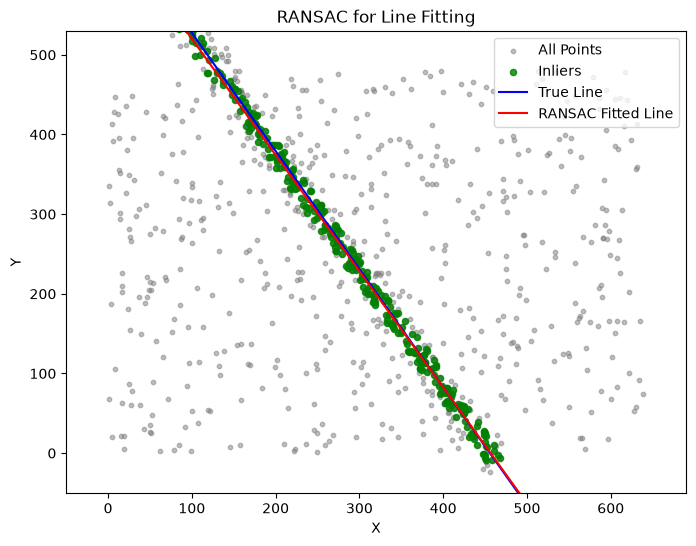

In [9]:
fig, ax = plt.subplots(figsize=(8,6))
ax.scatter(points[:,0], points[:,1], s=10, c='gray', alpha=0.5, label='All Points')
ax.scatter(inliers[:,0], inliers[:,1], s=20, c='green', alpha=0.8, label='Inliers')

p1 = (p[0] - 1000*dir_[0], p[1] - 1000*dir_[1])
p2 = (p[0] + 1000*dir_[0], p[1] + 1000*dir_[1])
ax.plot([p1[0], p2[0]], [p1[1], p2[1]], c='blue', label='True Line')

a, b, c = best_line
x_vals = np.linspace(0, 640, 2)
y_vals = (-a*x_vals - c) / b
ax.plot(x_vals, y_vals, c='red', label='RANSAC Fitted Line')

ax.set_xlim([-50, 690])
ax.set_ylim([-50, 530])
ax.set_xlabel('X')
ax.set_ylabel('Y')
ax.set_title('RANSAC for Line Fitting')
ax.legend()
plt.show()


## 6. Conclusion

Including the over-determined solution at the end of RANSAC (1 point)

In [ ]:
x = inliers[:, 0]
y = inliers[:, 1]

# matrix A -> (y = mx + q)
A = np.column_stack([x, np.ones(len(x))])

m, q = np.linalg.lstsq(A, y, rcond=None)[0]

# From y = mx + q to ax + by + c = 0 -> mx - y + q = 0
a_ls, b_ls, c_ls = m, -1, q

norm = np.linalg.norm([a_ls, b_ls])
a_ls /= norm
b_ls /= norm
c_ls /= norm

print(f"Least Square Over-determined line: a={a_ls:.3f}, b={b_ls:.3f}, c={c_ls:.3f}")
print(f"RANSAC 2-point line:               a={best_line[0]:.3f}, b={best_line[1]:.3f}, c={best_line[2]:.3f}")



Least Square Over-determined line: a=-0.826, b=-0.564, c=376.716
RANSAC 2-point line:               a=-0.825, b=-0.565, c=376.600


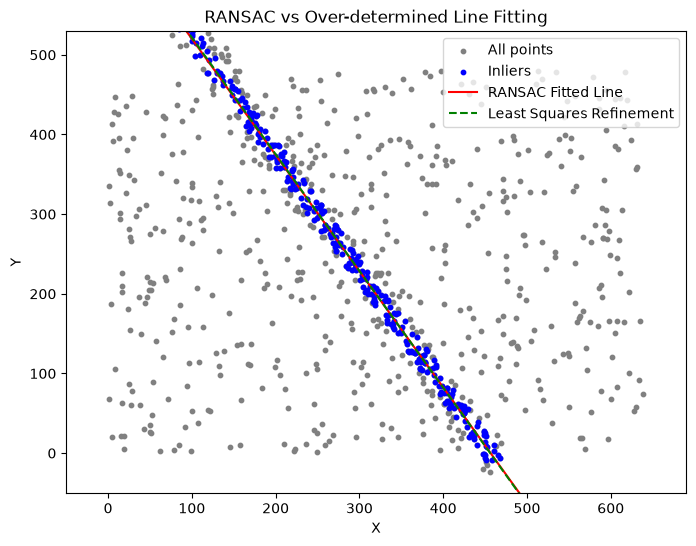

In [18]:
# Plotting
fig, ax = plt.subplots(figsize=(8, 6))

# Plot all points
ax.scatter(points[:, 0], points[:, 1], c='gray', s=10, label='All points')
# Plot inliers
ax.scatter(inliers[:, 0], inliers[:, 1], c='blue', s=10, label='Inliers')

x_vals = np.linspace(0, 640, 2)
if best_line[1] != 0:
    y_vals_ransac = (-best_line[0] * x_vals - best_line[2]) / best_line[1]
    ax.plot(x_vals, y_vals_ransac, c='red', label='RANSAC Fitted Line')

if b_ls != 0:
    y_vals_ls = (-a_ls * x_vals - c_ls) / b_ls
    ax.plot(x_vals, y_vals_ls, c='green', linestyle='--', label='Least Squares Refinement')

ax.set_xlim([-50, 690])
ax.set_ylim([-50, 530])
ax.set_xlabel('X')
ax.set_ylabel('Y')
ax.set_title('RANSAC vs Over-determined Line Fitting')
ax.legend()
plt.show()